# Agile Bioacoustic Modeling with SongSpace

This tutorial reproduces the core iterative workflow from the Hoplite agile modeling notebook, but uses `SongSpace` to manage datasets and shallow classifiers.

## Run this tutorial

If running in Colab, uncomment the installation line below.

In [1]:
# if 'google.colab' in str(get_ipython()):
#     %pip install "opensoundscape==0.12.1" "bioacoustics-model-zoo==0.12.0"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import bioacoustics_model_zoo as bmz

from opensoundscape.annotations import BoxedAnnotations
from opensoundscape.vector_database import load_or_create_hoplite_usearch_db
from opensoundscape.ml.song_space import SongSpace
from opensoundscape.ml.shallow_classifier import select_from_hoplite
from opensoundscape.visualization import annotate, inspect

## Prepare labels

This uses the same _Rana sierrae_ example files as the agile Hoplite tutorial.

In [4]:
dataset_path = Path("./rana_sierrae_2022/")
audio_and_raven_files = pd.read_csv(dataset_path / "audio_and_raven_files.csv")
audio_and_raven_files["audio"] = audio_and_raven_files["audio"].apply(
    lambda x: str(dataset_path / x)
)
audio_and_raven_files["raven"] = audio_and_raven_files["raven"].apply(
    lambda x: str(dataset_path / x)
)

annotations = BoxedAnnotations.from_raven_files(
    raven_files=audio_and_raven_files["raven"],
    audio_files=audio_and_raven_files["audio"],
    annotation_column="annotation",
)

labels = annotations.clip_labels(clip_duration=3, min_label_overlap=0.2)

/Users/SML161/opensoundscape/opensoundscape/annotations.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_annotations_df = pd.concat(all_file_dfs).reset_index(drop=True)


In [ ]:
target_source_class = "C"
target_model_class = "RanaSierrae_C"

# start with one recording of target class
binary_labels = labels[[target_source_class]].rename(
    columns={target_source_class: target_model_class}
)
seed_train = binary_labels.loc[
    ["rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220623_060000_0-10s.mp3"]
]
other = binary_labels.drop(seed_train.index)
validation, unlabeled = train_test_split(other, test_size=0.8, random_state=0)

print("seed_train:", seed_train.shape)
print("validation:", validation.shape)
print("pool:", unlabeled.shape)

seed_train: (4, 1)
validation: (536, 1)
pool: (2148, 1)


All audio clips from the single audio file we'll start with for positives:


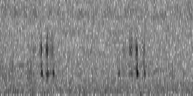
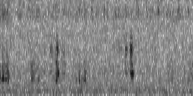
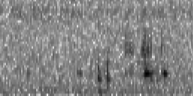
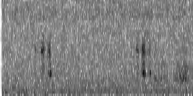

In [ ]:
_ = inspect(seed_train, bandpass_range=(0, 2500))

## Build database and SongSpace

In [50]:
ss = SongSpace("./ssdb")

downloading model from URL...
Creating new db at ssdb


In [51]:
# Embed and register datasets in SongSpace.
ss.ingest_audio(
    seed_train,
    dataset_name="round1_train",
    batch_size=32,
)
ss.ingest_audio(
    validation.sample(100),
    dataset_name="validation",
    allow_training=False,
    batch_size=32,
)
ss.ingest_audio(
    unlabeled.sample(100),
    dataset_name="pool_unlabeled",
    batch_size=32,
)

ss.list_datasets()

embedding 4 new windows to database


  0%|          | 0/1 [00:00<?, ?it/s]

embedding 100 new windows to database


  0%|          | 0/4 [00:00<?, ?it/s]

embedding 100 new windows to database


  0%|          | 0/4 [00:00<?, ?it/s]

['round1_train', 'validation', 'pool_unlabeled']

## Train first classifier

In [ ]:
clf_round1 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train"],
    validation_dataset="validation",
    weak_negatives_proportion=20.0,  # lots of weak negatives, since we have just 4 positives!
    weak_negatives_weight=0.01,
    steps=100,
    batch_size=128,
    validation_interval=25,
    logging_interval=25,
)
clf_round1.val_metrics

training classifier for 1 classes with 4 training samples and 100 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 25/100, Loss: 0.007, Val Loss: 4.289
	val AU ROC: 0.687
	val MAP: 0.059
Epoch 50/100, Loss: 0.003, Val Loss: 5.101
	val AU ROC: 0.667
	val MAP: 0.056
Epoch 75/100, Loss: 0.002, Val Loss: 5.373
	val AU ROC: 0.653
	val MAP: 0.054
Epoch 100/100, Loss: 0.002, Val Loss: 5.571
	val AU ROC: 0.649
	val MAP: 0.053
Loaded best model with validation loss: 4.289 at step 25 of 100
Training complete


{'loss': 4.288830280303955,
 'auroc': 0.6494845360824743,
 'map': 0.05328282828282828,
 'per_class_auroc': [0.6494845360824743]}

save the classifier in the SoundScape, if we like it enough

In [54]:
ss.add_classifier("rana_round1", clf_round1)

evaluate it

In [55]:
round1_metrics = ss.evaluate("rana_round1", "validation")
round1_metrics

Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

{'RanaSierrae_C': {'average_precision': 0.05328282828282828,
  'roc_auc': 0.6494845360824743},
 'macro_average_precision': np.float64(0.05328282828282828),
 'macro_roc_auc': np.float64(0.6494845360824743)}

## Active learning round: review high-scoring candidates

In [56]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round1", dataset_name="pool_unlabeled"
)
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,7.460848,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,7.322715,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,7.305774,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,7.243846,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,7.122934,None,None


format labels

In [57]:
new_pos = topk[topk["Accept"] == True][["file", "start_time", "end_time"]].copy()
new_pos[target_model_class] = 1

new_neg = topk[topk["Reject"] == True][["file", "start_time", "end_time"]].copy()
new_neg[target_model_class] = 0

round2_train = (
    pd.concat([new_pos, new_neg], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[[target_model_class]]
)
round2_train.shape

(20, 1)

## Retrain with expanded labels

In [59]:
ss.ingest_audio(
    round2_train,
    dataset_name="round2_train",
    batch_size=32,
    num_workers=0,
)

clf_round2 = ss.fit_classifier(
    classes=[target_model_class],
    train_datasets=["round1_train", "round2_train", "pool_unlabeled"],
    validation_dataset="validation",
    weak_negatives_proportion=5.0,
    weak_negatives_weight=0.01,
    steps=300,
    batch_size=128,
    validation_interval=25,
    logging_interval=25,
)
ss.add_classifier("rana_round2", clf_round2)

round2_metrics = ss.evaluate("rana_round2", "validation")
round2_metrics

all samples already have embeddings in the database
training classifier for 1 classes with 124 training samples and 100 validation samples
Finding matching window IDs for samples in label_df...
Finding matching window IDs for samples in label_df...
Epoch 25/300, Loss: 0.265, Val Loss: 0.127
	val AU ROC: 0.887
	val MAP: 0.157
Epoch 50/300, Loss: 0.201, Val Loss: 0.149
	val AU ROC: 0.983
	val MAP: 0.667
Epoch 75/300, Loss: 0.165, Val Loss: 0.125
	val AU ROC: 0.966
	val MAP: 0.567
Epoch 100/300, Loss: 0.142, Val Loss: 0.118
	val AU ROC: 0.952
	val MAP: 0.512
Epoch 125/300, Loss: 0.126, Val Loss: 0.111
	val AU ROC: 0.948
	val MAP: 0.505
Epoch 150/300, Loss: 0.115, Val Loss: 0.106
	val AU ROC: 0.952
	val MAP: 0.538
Epoch 175/300, Loss: 0.106, Val Loss: 0.102
	val AU ROC: 0.952
	val MAP: 0.538
Epoch 200/300, Loss: 0.098, Val Loss: 0.099
	val AU ROC: 0.955
	val MAP: 0.571
Epoch 225/300, Loss: 0.091, Val Loss: 0.096
	val AU ROC: 0.955
	val MAP: 0.622
Epoch 250/300, Loss: 0.086, Val Loss: 0.094

  0%|          | 0/1 [00:00<?, ?it/s]

{'RanaSierrae_C': {'average_precision': 0.6111111111111112,
  'roc_auc': 0.9450171821305842},
 'macro_average_precision': np.float64(0.6111111111111112),
 'macro_roc_auc': np.float64(0.9450171821305842)}

In [61]:
pool_scores = ss.predict_on_dataset(
    classifier_name="rana_round2", dataset_name="pool_unlabeled"
)
topk = pool_scores.nlargest(20, target_model_class).reset_index()

# Review and annotate interactively.
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)
topk.head()

Finding matching window IDs for samples in label_df...


  0%|          | 0/1 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

,file,start_time,end_time,RanaSierrae_C,Accept,Reject
0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,0.254953,None,None
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,0.127380,None,None
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,-0.315459,None,None
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,-0.511502,None,None
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,-1.434558,None,None


## Select clips for manual verification

Use stratified or thresholded selection from the full embedded database.

In [60]:
selected = select_from_hoplite(
    ss.db,
    ss.classifiers["rana_round2"],
    classes=[target_model_class],
    strategy="top_k",
    k=20,
    min_score=0,
)
selected.head()

,file,start_time,end_time,score,datetime,deployment,project,class
1,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,0.0,3.0,3.206382,2022-06-23 06:00:00,mp3,round1_train,RanaSierrae_C
2,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,2.639465,2022-06-23 06:00:00,mp3,round1_train,RanaSierrae_C
3,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,6.0,9.0,3.036186,2022-06-23 06:00:00,mp3,round1_train,RanaSierrae_C
4,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,9.0,12.0,0.256542,2022-06-23 06:00:00,mp3,round1_train,RanaSierrae_C
189,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,3.0,6.0,0.127380,2022-06-20 09:30:00,mp3,round1_train,RanaSierrae_C


In [ ]:
# Optional cleanup
# import shutil
# shutil.rmtree('./songspace_agile_db/')